In [1]:
import numpy as np
from scipy.special import jv
from scipy.linalg import inv
import time
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from joblib import Parallel, delayed
import multiprocessing

# --- 1. 全局设置 ---
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.size'] = 18
plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

In [25]:
class GWNetworkSimulator:
    def __init__(self, detectors):
        """
        初始化探测器网络。
        """
        self.detectors = detectors
        self.N = len(detectors)
        
        # 预计算探测器的位置向量 (Global Cartesian) 和 指向向量
        self.pos_vecs = []
        self.orient_vecs = []
        self.P_inst_list = []
        
        for det in detectors:
            r, theta, phi = det['pos_r'], det['pos_theta'], det['pos_phi']
            pos = self._sph2cart(r, theta, phi)
            self.pos_vecs.append(pos)
            
            nr, nt, nphi = det['n_r'], det['n_theta'], det['n_phi']
            
            # 局部球坐标基底在全局笛卡尔系中的表示
            er = np.array([np.sin(theta)*np.cos(phi), np.sin(theta)*np.sin(phi), np.cos(theta)])
            et = np.array([np.cos(theta)*np.cos(phi), np.cos(theta)*np.sin(phi), -np.sin(theta)])
            ep = np.array([-np.sin(phi), np.cos(phi), 0.0])
            
            orient = nr * er + nt * et + nphi * ep
            # 防止零向量归一化报错
            norm = np.linalg.norm(orient)
            if norm > 0:
                self.orient_vecs.append(orient / norm)
            else:
                self.orient_vecs.append(orient)
            
            self.P_inst_list.append(det.get('P_inst', 1e-30))

        self.pos_vecs = np.array(self.pos_vecs)
        self.orient_vecs = np.array(self.orient_vecs)

    def _sph2cart(self, r, theta, phi):
        return np.array([
            r * np.sin(theta) * np.cos(phi),
            r * np.sin(theta) * np.sin(phi),
            r * np.cos(theta)
        ])

    def compute_noise_matrix_C(self, f, c_R, S_n_R, nu_Rayleigh, P_inst_override=None):
        """
        计算噪声矩阵 C (N x N, complex).
        包含仪器自噪声 + Haney Rayleigh背景噪声
        """
        # 在函数内部导入 jv 以支持 joblib 并行
        from scipy.special import jv
        
        C = np.zeros((self.N, self.N), dtype=complex)
        
        P_vals = P_inst_override if P_inst_override is not None else self.P_inst_list
        for i in range(self.N):
            C[i, i] = P_vals[i]
            
        for i in range(self.N):
            for j in range(self.N):
                vec_ij = self.pos_vecs[j] - self.pos_vecs[i]
                dist = np.linalg.norm(vec_ij)
                
                # 构建局部坐标系 (Z, R, T)
                z_axis = self.pos_vecs[i] / np.linalg.norm(self.pos_vecs[i])
                
                proj = vec_ij - np.dot(vec_ij, z_axis) * z_axis
                if np.linalg.norm(proj) < 1e-9:
                    # 如果位置重合(i=j)，任意选一个切向方向作为 R 轴
                    # 这里简单的选 (0,1,0) 并正交化，或者使用预计算的切向基
                    # 只要 J1(0)=0，J0(0)=1，方向并不影响自功率谱结果
                    r_axis = np.array([0, 1, 0]) 
                else:
                    r_axis = proj / np.linalg.norm(proj)
                
                t_axis = np.cross(z_axis, r_axis)
                
                R_rot = np.vstack([z_axis, r_axis, t_axis]) 
                
                # Haney Matrix 计算
                k_R = 2 * np.pi * f / c_R
                zeta = k_R * dist
                
                j0_z = jv(0, zeta)
                j1_z = jv(1, zeta)
                j2_z = jv(2, zeta)
                
                nu = nu_Rayleigh
                
                Phi = np.zeros((3, 3), dtype=complex)
                Phi[0, 0] = j0_z
                Phi[0, 1] = -nu * j1_z
                Phi[1, 0] = nu * j1_z
                Phi[1, 1] = (nu**2 / 2) * (j0_z - j2_z)
                Phi[2, 2] = (nu**2 / 2) * (j0_z + j2_z)
                
                Phi *= S_n_R
                
                n_i_local = R_rot @ self.orient_vecs[i]
                n_j_local = R_rot @ self.orient_vecs[j]
                
                corr_val = n_i_local.T @ Phi @ n_j_local
                
                # 累加噪声：C_ij = P_inst * delta_ij + Correlation
                C[i, j] = C[i, j] + corr_val
                
        return C

    def compute_signal_vector(self, h0, Tr, Th, e_val, lambda_val, nu_val):
        """
        计算特定方向(e, lambda)和极化(nu)下的信号向量 s.
        不再进行全天积分，而是返回一个长度为 N 的复数向量。
        """
        # 1. 计算基向量 (e_e, e_lambda)
        # Global Coordinates
        # e_e = (cos e cos lambda, cos e sin lambda, -sin e)
        ee = np.array([
            np.cos(e_val) * np.cos(lambda_val),
            np.cos(e_val) * np.sin(lambda_val),
            -np.sin(e_val)
        ])
        
        # e_lambda = (-sin lambda, cos lambda, 0)
        el = np.array([
            -np.sin(lambda_val),
            np.cos(lambda_val),
            0.0
        ])
        
        # 2. 计算极化张量分量向量 l 和 m
        # l = cos(nu)(-e_e) + sin(nu)(-e_l)
        l_vec = np.cos(nu_val) * (-ee) + np.sin(nu_val) * (-el)
        
        # m = sin(nu)(e_e) + cos(nu)(-e_l)
        m_vec = np.sin(nu_val) * (ee) + np.cos(nu_val) * (-el)
        
        # 3. 构造 GW 极化张量 epsilon (3x3)
        # epsilon = (l x l - m x m) + (l x m + m x l)
        #epsilon = (np.outer(l_vec, l_vec) - np.outer(m_vec, m_vec)) + \
                  #(np.outer(l_vec, m_vec) + np.outer(m_vec, l_vec))
        #epsilon = (np.outer(l_vec, l_vec) - np.outer(m_vec, m_vec)) 
        epsilon = (np.outer(l_vec, m_vec) + np.outer(m_vec, l_vec))
        
        # 4. 计算每个探测器的响应 s_i
        s_vec = np.zeros(self.N, dtype=complex)
        
        for i in range(self.N):
            r_hat = self.pos_vecs[i] / np.linalg.norm(self.pos_vecs[i])
            n_hat = self.orient_vecs[i]
            
            # term1: h . r_hat (Result is vector 3)
            h_dot_r = epsilon @ r_hat
            
            # term2: r_hat . h . r_hat (Scalar)
            r_dot_h_dot_r = np.dot(r_hat, h_dot_r)
            
            # xi vector: 2 Th (h.r) + (Tr - 2Th) (r.h.r) r
            xi = 2 * Th * h_dot_r + (Tr - 2 * Th) * r_dot_h_dot_r * r_hat
            
            # response s = xi . n
            s_vec[i] = np.dot(xi, n_hat) * h0
            
        return s_vec

    def calculate_snr(self, f, h0, Tr, Th, c_R, S_n_R, nu_Rayleigh, e_val, lambda_val, nu_val):
        """
        计算特定参数下的 SNR^2 = s^dag * C^-1 * s
        """
        # 1. 计算噪声矩阵 C
        C = self.compute_noise_matrix_C(f, c_R, S_n_R, nu_Rayleigh)
        
        # 2. 求逆 (带正则化)
        try:
            C_inv = inv(C)
        except np.linalg.LinAlgError:
            print("Warning: Matrix C is singular, adding regularization.")
            C_inv = inv(C + np.eye(self.N) * 1e-30)
            
        # 3. 计算信号向量 s
        s_vec = self.compute_signal_vector(h0, Tr, Th, e_val, lambda_val, nu_val)
        
        # 4. 计算 SNR^2
        # s^dag * C^-1 * s
        # np.vdot(a, b) handles complex conjugation of a: a^H . b
        result = np.vdot(s_vec, C_inv @ s_vec)
        
        # 结果理论上是实数
        return np.real(result)

In [26]:
# 2. Worker 函数: 单个网格点的计算逻辑
# ==========================================
def calculate_single_point(d_km_east, d_km_south, 
                                f_target, R_moon, 
                                P_inst_val, S_n_R_val, 
                                Tr_val, Th_val, c_R_val, nu_Rayleigh_val,
                                e_val, lambda_val, nu_val): # <--- 新增入射角参数
    """
    计算给定偏移量下的四探测器阵列响应 (特定入射角).
    """
    
    # --- A. 基础几何计算 ---
    d_m_east = d_km_east * 1000
    delta_phi = d_m_east / R_moon  # 赤道上的经度变化
    
    d_m_south = d_km_south * 1000
    delta_theta = d_m_south / R_moon # 纬度变化

    # --- B. 定义探测器阵列 (4个探测器) ---
    # 组 1: 位于原点 (赤道, phi=0)
    det1 = {
        'pos_r': R_moon, 'pos_theta': np.pi/2, 'pos_phi': 0.0,
        'n_r': 0.0, 'n_theta': 0.0, 'n_phi': 1.0, # 指向 East
        'P_inst': P_inst_val
    }
    det1v = {
        'pos_r': R_moon, 'pos_theta': np.pi/2, 'pos_phi': 0.0,
        'n_r': 0.0, 'n_theta': 1.0, 'n_phi': 0.0, # 指向 South
        'P_inst': P_inst_val
    }

    # 组 2: 位于偏移点
    det2 = {
        'pos_r': R_moon, 
        'pos_theta': np.pi/2 + delta_theta, 
        'pos_phi': delta_phi,
        'n_r': 0.0, 'n_theta': 0, 'n_phi': 1, # 指向 East
        'P_inst': P_inst_val
    }
    det2v = {
        'pos_r': R_moon, 
        'pos_theta': np.pi/2 + delta_theta, 
        'pos_phi': delta_phi,
        'n_r': 0.0, 'n_theta': 1, 'n_phi': 0, # 指向 South
        'P_inst': P_inst_val
    }

    # --- C. 实例化与计算 ---
    sim = GWNetworkSimulator([det1, det1v, det2, det2v])
    
    # 执行特定方向的 SNR 计算
    snr_sq = sim.calculate_snr(
        f=f_target,
        h0=1.0,
        Tr=Tr_val, Th=Th_val,
        c_R=c_R_val,
        S_n_R=S_n_R_val,
        nu_Rayleigh=nu_Rayleigh_val,
        e_val=e_val,          # <---
        lambda_val=lambda_val,# <--- 传入指定参数
        nu_val=nu_val         # <---
    )
    return snr_sq

# ==========================================
# 3. Driver 函数: 参数配置与并行控制
# ==========================================
def run_parallel_sweep(n_jobs=-1):
    
    # --- [配置区域] 请在这里调整参数 ---
    
    # 1. 物理环境参数
    PARAMS = {
        'f_target': 0.3,         # 频率 Hz
        'R_moon':   1737.1e3,    # 月球半径 m
        'P_inst':   1.0,         # 仪器自噪声
        'S_n_R':    100.0,       # 瑞利波背景 PSD
        'Tr':       1e8,         # 径向响应
        'Th':       1e6,         # 水平响应
        'c_R':      500.0,       # 瑞利波速 m/s
        'nu_Rayleigh': 0.5,      # H/V 比 (椭率)
        
        # --- 新增: 手动指定的引力波入射参数 (弧度) ---
        'e_input':      np.pi/2,   # 仰角 e (0~pi)
        'lambda_input': 0,       # 方位角 lambda (0~2pi)
        'nu_input':     0        # 极化角 nu (0~pi)
    }

    # 2. 扫描网格设置
    # axis 1: 沿赤道偏移 (phi方向)
    d_vals_east = np.linspace(-4, 4, 400)  
    
    # axis 2: 沿经线偏移 (theta方向)
    d_vals_south = np.linspace(-4, 4, 400) 
    
    # ----------------------------------
    
    print(f"--- 开始并行模拟 (Fixed Source) ---")
    print(f"Source Params: e={PARAMS['e_input']:.2f}, lambda={PARAMS['lambda_input']:.2f}, nu={PARAMS['nu_input']:.2f}")
    print(f"网格大小: {len(d_vals_east)} x {len(d_vals_south)}")
    
    start_time = time.time()
    
    tasks = [
        (d_e, d_s) 
        for d_e in d_vals_east 
        for d_s in d_vals_south
    ]
    
    # 并行执行
    results_flat = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(calculate_single_point)(
            d_e, d_s, 
            PARAMS['f_target'], PARAMS['R_moon'], 
            PARAMS['P_inst'], PARAMS['S_n_R'], 
            PARAMS['Tr'], PARAMS['Th'], PARAMS['c_R'], PARAMS['nu_Rayleigh'],
            PARAMS['e_input'], PARAMS['lambda_input'], PARAMS['nu_input']
        ) 
        for d_e, d_s in tasks
    )
    
    # 结果重组
    results_grid = np.array(results_flat).reshape(len(d_vals_east), len(d_vals_south))
    
    elapsed = time.time() - start_time
    print(f"计算完成，耗时: {elapsed:.2f} 秒")
    
    return d_vals_east, d_vals_south, results_grid

In [27]:
if __name__ == "__main__":
    # 运行模拟
    # 请根据您的 CPU 核心数调整 n_jobs
    d_e, d_s, res_grid = run_parallel_sweep(n_jobs=16)
    
    

--- 开始并行模拟 (Fixed Source) ---
Source Params: e=1.57, lambda=0.00, nu=0.00
网格大小: 400 x 400


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  48 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 512 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done 6112 tasks      | elapsed:    1.2s
[Parallel(n_jobs=16)]: Done 16480 tasks      | elapsed:    3.2s
[Parallel(n_jobs=16)]: Done 29152 tasks      | elapsed:    5.6s
[Parallel(n_jobs=16)]: Done 44128 tasks      | elapsed:    8.4s
[Parallel(n_jobs=16)]: Done 61408 tasks      | elapsed:   11.5s
[Parallel(n_jobs=16)]: Done 80992 tasks      | elapsed:   15.2s
[Parallel(n_jobs=16)]: Done 102880 tasks      | elapsed:   19.3s
[Parallel(n_jobs=16)]: Done 127072 tasks      | elapsed:   23.7s
[Parallel(n_jobs=16)]: Done 153568 tasks      | elapsed:   28.6s


计算完成，耗时: 30.25 秒


[Parallel(n_jobs=16)]: Done 160000 out of 160000 | elapsed:   30.1s finished


In [28]:
# 4. 绘图与执行
# ==========================================
def plot_results_fixed_source(d_east, d_south, grid):
    plt.figure(figsize=(8, 6))
    
    # X轴: d_east, Y轴: d_south (注意 meshgrid 顺序)
    # 这里的 grid[i, j] 对应 d_east[i] 和 d_south[j]
    # 若要横轴为 east，纵轴为 south，则需转置或正确对应
    X, Y = np.meshgrid(d_east, d_south)
    
    # 归一化绘图 (相对于第一个点)
    # 注意 grid 需要转置以匹配 meshgrid(x,y) 的形状，如果 grid 是 (Nx, Ny)
    # 通常 pcolormesh(X, Y, C) 中 C 的 shape 应为 (Ny, Nx) -> (len(Y), len(X))
    # 这里 results_grid shape 是 (len(east), len(south))
    # X shape 是 (len(south), len(east))
    # 所以需要 grid.T
    
    # 设置显示范围 (可根据需要调整)
    # lowr = 0.8
    # upr = 6
    
    plt.pcolormesh(X, Y, grid.T/grid[300,300], 
                   cmap='viridis', 
                   shading='auto')
                   # vmin=lowr, vmax=upr)

    cb = plt.colorbar()
    cb.set_label(r'SNR$^2$ density $\mathcal{R} $')

    plt.plot(2, 2, 'r+', markersize=12, markeredgewidth=2)
    
    #plt.title(r'(b) Performance for ($\times$) polarization, $\left ( e,\lambda \right ) =\left ( \pi /2,0 \right ) $')
    plt.xlabel('$d_1$ (km)')
    plt.ylabel('$d_2$ (km)')
    
    plt.tight_layout()
    plt.show()

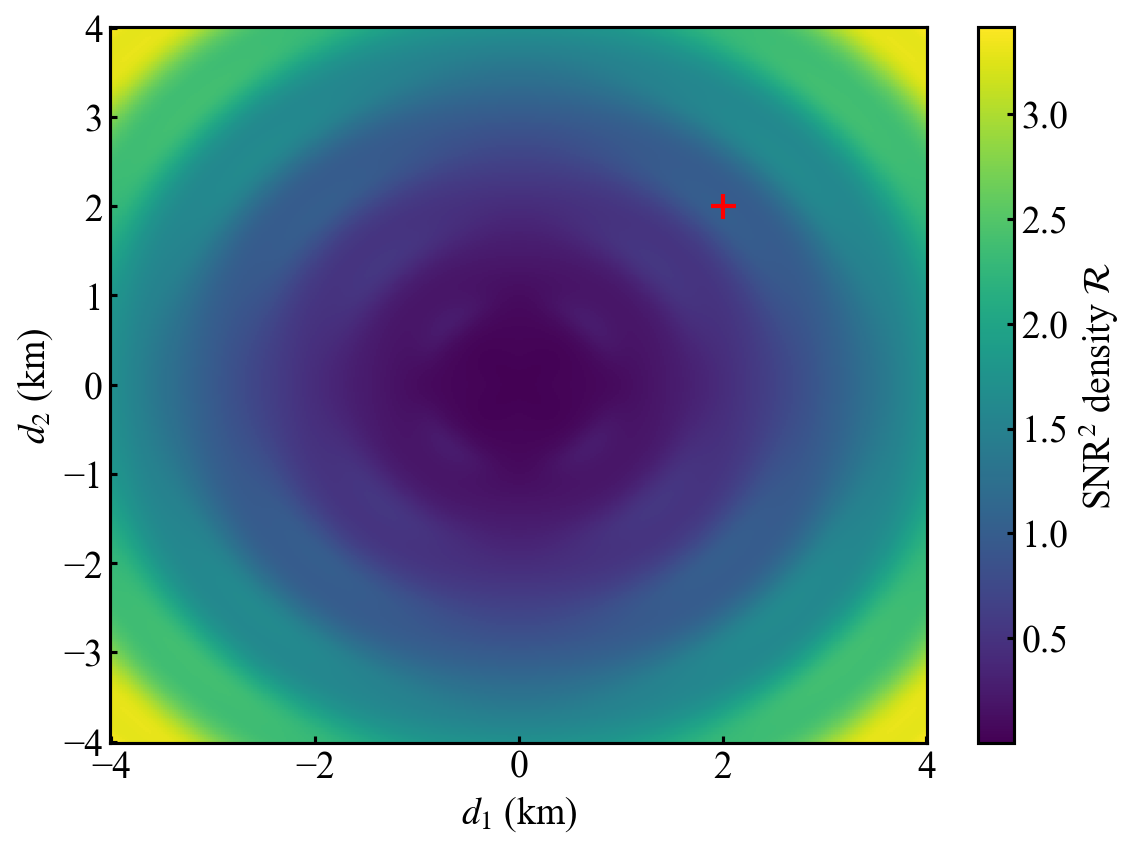

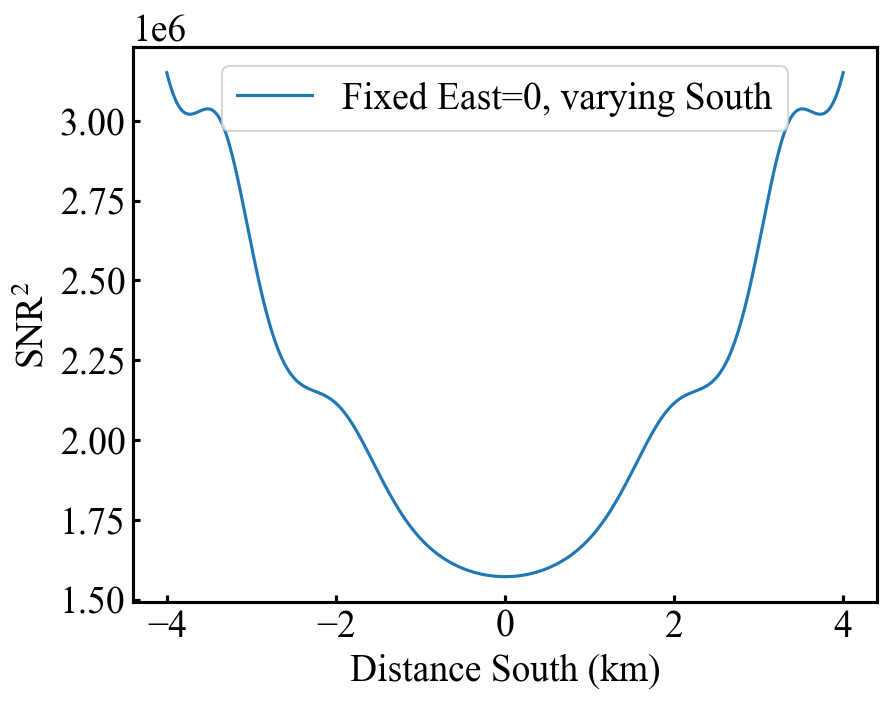

In [29]:

plot_results_fixed_source(d_e, d_s, res_grid)
    
# 简单的曲线检查
plt.figure()
plt.plot(d_s, res_grid[0,:], label='Fixed East=0, varying South')
plt.xlabel('Distance South (km)')
plt.ylabel('SNR$^2$')

plt.legend()
plt.show()